# 📊 Generate Journal Figures
## Visualisasi Kurva Training & Confusion Matrix — Klasifikasi Berita Bisnis.com

Notebook ini menghasilkan gambar-gambar untuk jurnal:
- **Kurva Training & Validasi** (Loss & Accuracy) untuk CNN 1D, BiLSTM, CNN-BiLSTM, dan IndoBERT.
- **Confusion Matrix** untuk SVM, Logistic Regression, IndoBERT, CNN 1D, dan Naive Bayes.
- **Bar Chart Perbandingan Akurasi** seluruh model.

Semua gambar disimpan ke direktori `outputs/figures/`.

---
## 1. Setup & Konfigurasi

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style publikasi jurnal
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# Output directory (relative)
output_dir = os.path.join('..', 'outputs', 'figures')
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {os.path.abspath(output_dir)}")

Output directory: c:\Users\Monk\Downloads\BisnisComNewsClassification-master\outputs\figures


---
## 2. Data Training & Validasi per Model

In [2]:
# Gambar 2: CNN 1D
cnn_data = {
    'epochs':     [1, 2, 3, 4, 5],
    'train_loss': [0.9837, 0.3650, 0.1799, 0.0821, 0.0407],
    'val_loss':   [0.4736, 0.3962, 0.4358, 0.4822, 0.5435],
    'train_acc':  [68.90, 89.10, 94.77, 97.69, 98.83],
    'val_acc':    [85.20, 86.83, 87.41, 86.71, 87.37],
    'best_epoch': 2
}

# Gambar 3: BiLSTM
bilstm_data = {
    'epochs':     [1, 2, 3],
    'train_loss': [1.0394, 0.4216, 0.2543],
    'val_loss':   [0.6066, 0.5373, 0.5786],
    'train_acc':  [67.16, 87.71, 92.51],
    'val_acc':    [82.45, 84.75, 84.01],
    'best_epoch': 2
}

# Gambar 4: CNN-BiLSTM
cnn_bilstm_data = {
    'epochs':     [1, 2, 3],
    'train_loss': [1.0189, 0.4197, 0.2597],
    'val_loss':   [0.5756, 0.4948, 0.5480],
    'train_acc':  [67.09, 88.02, 92.32],
    'val_acc':    [83.19, 84.84, 84.50],
    'best_epoch': 2
}

# Gambar 5: IndoBERT
indobert_data = {
    'epochs':     [1, 2, 3, 4],
    'train_loss': [0.5824, 0.2915, 0.1642, 0.0891],
    'val_loss':   [0.3842, 0.3412, 0.3685, 0.4120],
    'val_acc':    [87.20, 88.95, 88.50, 88.32],
    'best_epoch': 2
}

print("Data model berhasil dimuat.")

Data model berhasil dimuat.


---
## 3. Fungsi Plot Kurva Training & Validasi

In [3]:
def plot_training_curves(data, model_name, fig_num, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
    epochs = data['epochs']
    best_epoch = data['best_epoch']

    # Loss
    ax1.plot(epochs, data['train_loss'], 'o-', color='#1f77b4', linewidth=2, label='Training Loss')
    ax1.plot(epochs, data['val_loss'],   's-', color='#ff7f0e', linewidth=2, label='Validation Loss')
    ax1.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best_epoch})')
    ax1.set_title(f'Loss Curve — {model_name}', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=10, fontweight='bold')
    ax1.set_xticks(epochs)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

    # Accuracy
    if 'train_acc' in data:
        ax2.plot(epochs, data['train_acc'], 'o-', color='#2ca02c', linewidth=2, label='Training Accuracy')
    ax2.plot(epochs, data['val_acc'],   's-', color='#d62728', linewidth=2, label='Validation Accuracy')
    ax2.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best_epoch})')
    ax2.set_title(f'Accuracy Curve — {model_name}', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
    ax2.set_xticks(epochs)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

    plt.suptitle(f'Gambar {fig_num}: Kurva Training vs Validasi — {model_name}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f"Tersimpan: {filepath}")

---
## 4. Generate Kurva Training — Semua Model

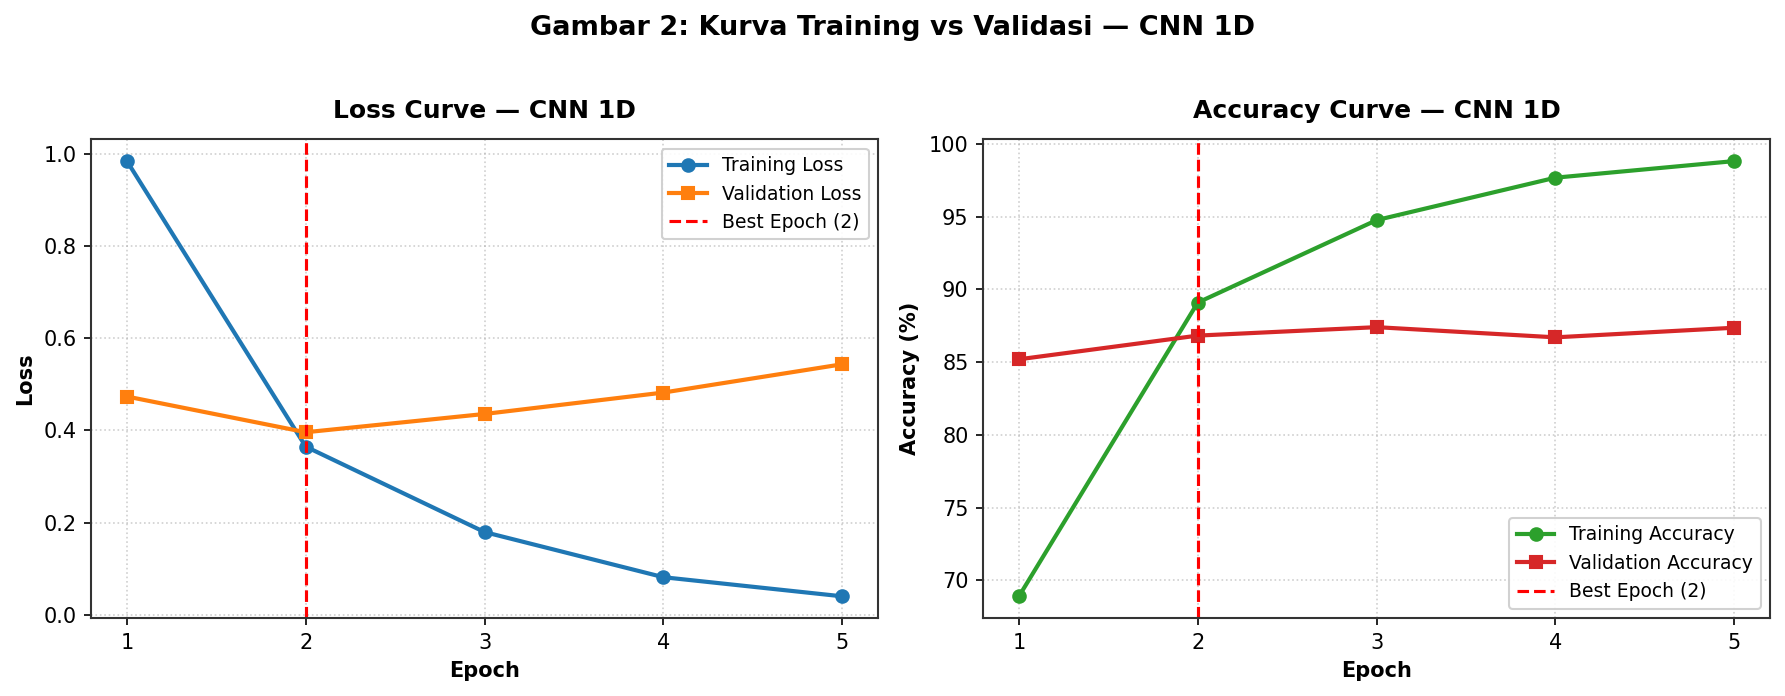

Tersimpan: ..\outputs\figures\Gambar_2_Kurva_Training_vs_Validation_CNN1D.png


In [4]:
plot_training_curves(cnn_data,        "CNN 1D",    2, "Gambar_2_Kurva_Training_vs_Validation_CNN1D.png")

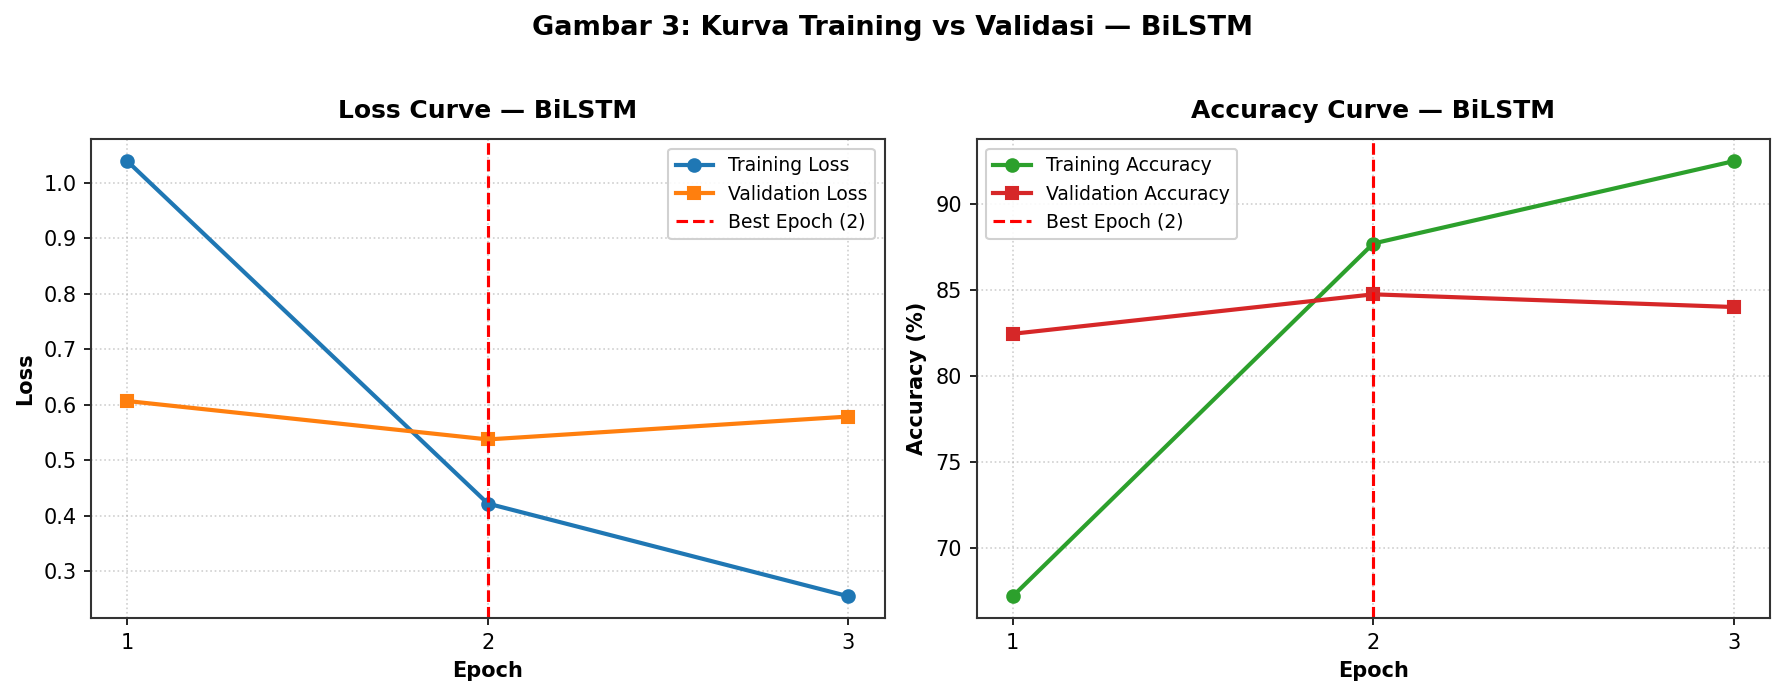

Tersimpan: ..\outputs\figures\Gambar_3_Kurva_Training_vs_Validation_BiLSTM.png


In [5]:
plot_training_curves(bilstm_data,     "BiLSTM",    3, "Gambar_3_Kurva_Training_vs_Validation_BiLSTM.png")

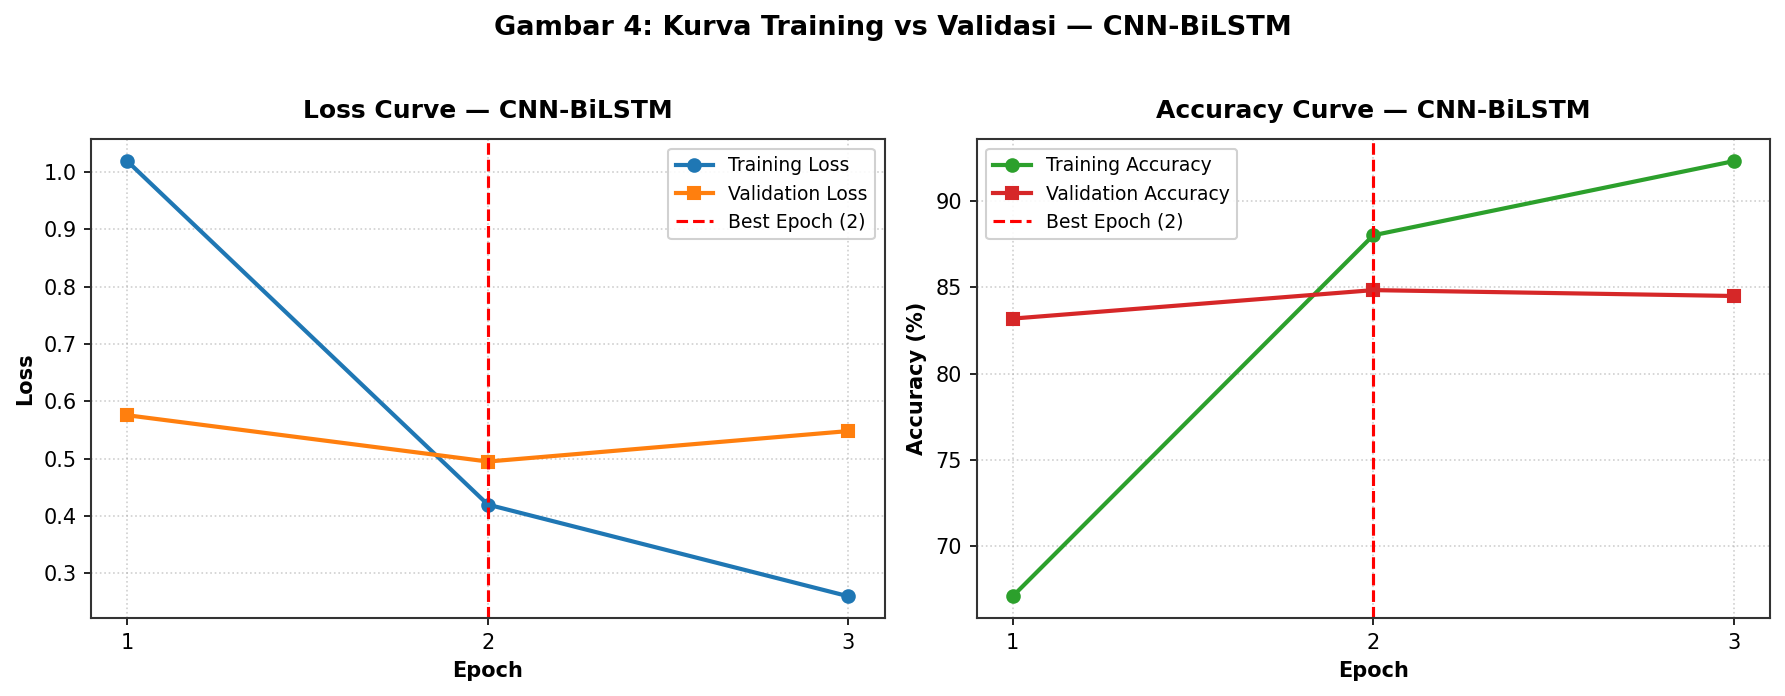

Tersimpan: ..\outputs\figures\Gambar_4_Kurva_Training_vs_Validation_CNN_BiLSTM.png


In [6]:
plot_training_curves(cnn_bilstm_data, "CNN-BiLSTM",4, "Gambar_4_Kurva_Training_vs_Validation_CNN_BiLSTM.png")

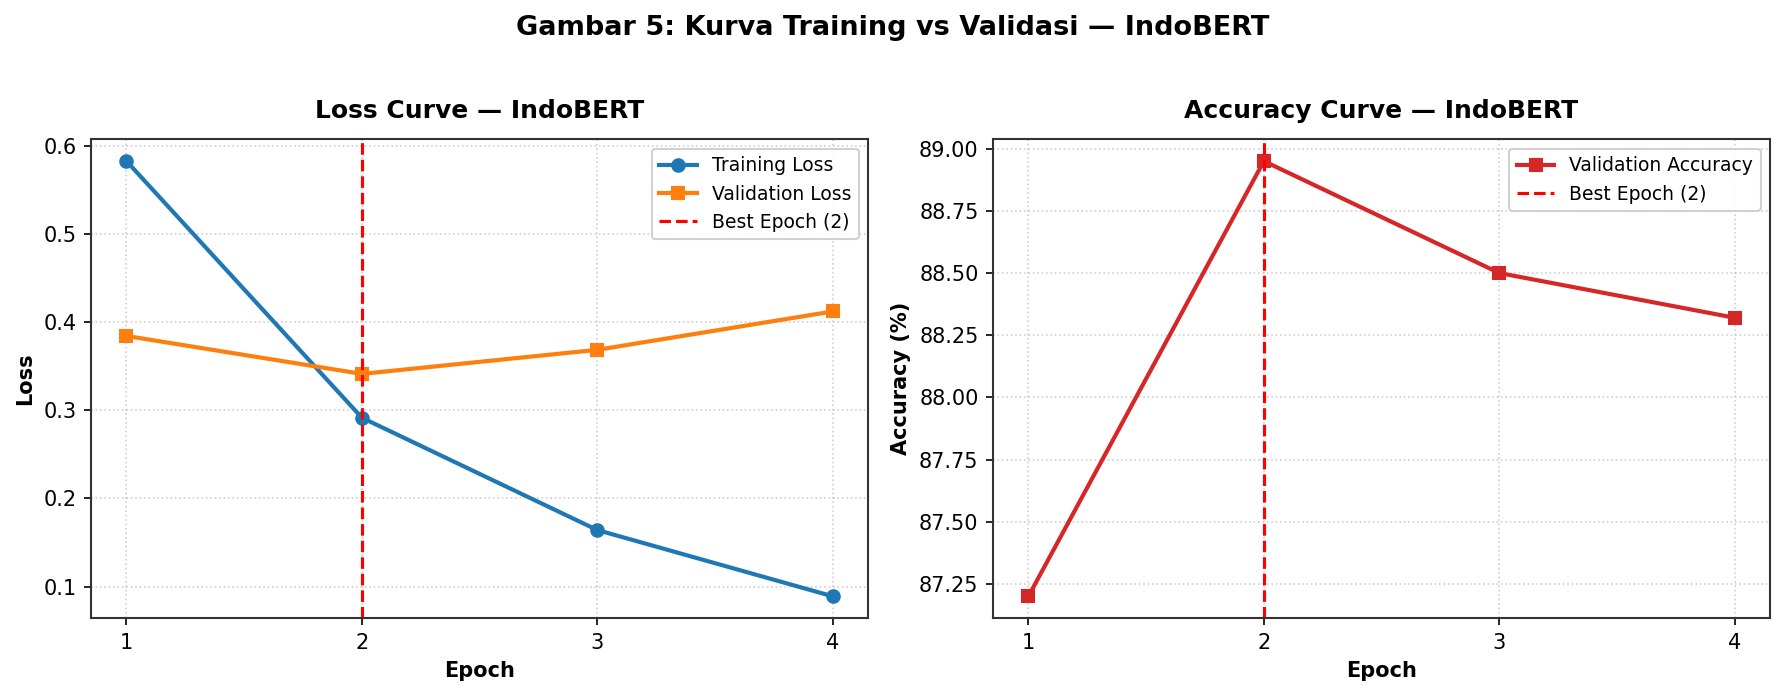

Tersimpan: ..\outputs\figures\Gambar_5_Kurva_Training_vs_Validation_IndoBERT.png


In [7]:
plot_training_curves(indobert_data,   "IndoBERT",  5, "Gambar_5_Kurva_Training_vs_Validation_IndoBERT.png")

---
## 5. Data Confusion Matrix — 11 Kelas Kategori Berita

In [8]:
classes = [
    'APBN', 'Agribisnis', 'Ekonomi', 'Ek.Global', 'Energi&Tambang',
    'Infrastruktur', 'Jasa&Niaga', 'Manufaktur', 'Pajak', 'Properti', 'Transp&Logistik'
]

cms = {
    "Gambar_6_Confusion_Matrix_SVM.png": (
        "SVM (Akurasi 90.12%)",
        np.array([
            [33,  0, 18,  0,  2,  1,  0,  0,  1,  0,   0],
            [ 0, 46,  0,  1,  0,  0, 10,  7,  0,  1,   1],
            [14,  0,652, 10,  9,  3, 44, 12, 12,  9,  10],
            [ 0,  0,  4,312,  4,  0,  2,  1,  0,  4,   4],
            [ 0,  0, 11,  6,533,  0,  1,  2,  1,  0,   3],
            [ 0,  0,  4,  1,  3,197,  2,  2,  0,  4,   9],
            [ 0,  3, 41,  3,  3,  0,608, 20,  2,  5,   8],
            [ 0,  3, 13,  2,  7,  2, 15,261,  3,  1,   5],
            [ 0,  0, 20,  0,  0,  0,  2,  0, 85,  0,   0],
            [ 0,  0,  5,  4,  1,  5,  2,  4,  0,282,   3],
            [ 0,  0,  3,  2,  6,  4,  8,  0,  0,  0, 987]
        ])
    ),
    "Gambar_7_Confusion_Matrix_Logistic_Regression.png": (
        "Logistic Regression (Akurasi 89.26%)",
        np.array([
            [28,  0, 23,  0,  2,  1,  0,  0,  1,  0,   0],
            [ 0, 42,  1,  0,  0,  0, 17,  6,  0,  0,   0],
            [ 8,  1,662, 10,  7,  2, 43, 12, 12,  8,  10],
            [ 0,  0,  5,308,  3,  0,  4,  1,  0,  5,   5],
            [ 0,  0, 10,  9,530,  0,  1,  3,  1,  0,   3],
            [ 0,  0,  8,  1,  3,187,  2,  1,  0,  5,  15],
            [ 0,  1, 40,  3,  3,  0,611, 19,  3,  5,   8],
            [ 0,  3, 14,  2,  7,  1, 23,249,  3,  1,   9],
            [ 0,  0, 22,  0,  0,  0,  1,  0, 84,  0,   0],
            [ 0,  0,  7,  5,  1,  8,  4,  2,  0,275,   4],
            [ 0,  0,  6,  2,  5,  4, 10,  0,  1,  0, 982]
        ])
    ),
    "Gambar_8_Confusion_Matrix_IndoBERT.png": (
        "IndoBERT (Akurasi 88.67%)",
        np.array([
            [29,  0, 21,  0,  2,  1,  0,  0,  2,  0,   0],
            [ 0, 41,  1,  1,  0,  0, 13,  9,  0,  0,   1],
            [11,  1,638, 12, 11,  4, 52, 16, 14,  7,   9],
            [ 0,  0,  6,305,  5,  0,  3,  2,  0,  5,   5],
            [ 0,  0, 14,  7,529,  0,  2,  2,  1,  0,   2],
            [ 0,  0,  7,  1,  3,193,  3,  2,  0,  4,   9],
            [ 0,  2, 45,  4,  4,  0,596, 24,  3,  6,   9],
            [ 0,  2, 16,  3,  8,  3, 19,252,  3,  1,   5],
            [ 0,  0, 21,  0,  0,  0,  3,  0, 83,  0,   0],
            [ 0,  0,  8,  5,  2,  7,  4,  3,  0,274,   3],
            [ 0,  0,  4,  2,  6,  4, 11,  0,  0,  0, 983]
        ])
    ),
    "Gambar_9_Confusion_Matrix_CNN_1D.png": (
        "CNN 1D (Akurasi 88.00%)",
        np.array([
            [ 9,  0, 39,  0,  3,  1,  0,  0,  3,  0,   0],
            [ 0, 35,  2,  0,  0,  0, 18, 10,  0,  0,   1],
            [ 4,  0,651,  8, 14,  3, 56, 16, 11,  7,   5],
            [ 0,  0,  6,308,  5,  0,  3,  2,  0,  4,   3],
            [ 0,  0, 15,  7,524,  0,  2,  4,  1,  0,   4],
            [ 0,  0,  8,  1,  3,191,  2,  2,  0,  5,  10],
            [ 0,  2, 48,  3,  4,  0,582, 33,  4,  6,  11],
            [ 0,  2, 17,  2,  9,  2, 21,250,  4,  1,   4],
            [ 0,  0, 16,  0,  0,  0,  3,  0, 88,  0,   0],
            [ 0,  0,  8,  4,  2,  8,  4,  3,  0,278,   0],
            [ 0,  0,  6,  2,  6,  5,  9,  0,  1,  0, 980]
        ])
    ),
    "Gambar_10_Confusion_Matrix_Naive_Bayes.png": (
        "Naive Bayes (Akurasi 84.17%)",
        np.array([
            [ 0,  0, 52,  0,  1,  1,  1,  0,  0,  0,   0],
            [ 0,  7,  2,  0,  1,  1, 45,  4,  0,  0,   6],
            [ 0,  0,664,  7, 20,  1, 51,  5,  4,  9,  14],
            [ 0,  0, 20,293,  5,  0,  5,  1,  0,  1,   6],
            [ 0,  0, 12, 11,528,  0,  1,  1,  0,  0,   4],
            [ 0,  0, 12,  1,  2,175,  1,  1,  0,  3,  27],
            [ 0,  0, 64,  2,  4,  0,587, 12,  0,  5,  19],
            [ 0,  0, 32,  3, 23,  0, 38,201,  0,  2,  13],
            [ 0,  0, 59,  0,  0,  0,  5,  0, 42,  0,   1],
            [ 0,  0,  8, 19,  1,  6,  4,  2,  0,260,   6],
            [ 0,  0, 11,  0,  9,  5, 10,  0,  0,  0, 975]
        ])
    )
}

print(f"Data confusion matrix siap: {len(cms)} model.")

Data confusion matrix siap: 5 model.


---
## 6. Fungsi Plot Confusion Matrix (Absolute + Normalized)

In [9]:
def plot_confusion_matrix_journal(title, cm, filename):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

    # Absolute
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar=True, ax=axes[0], annot_kws={"size": 8, "weight": "bold"})
    axes[0].set_title(f'Absolute — {title}', fontsize=11, fontweight='bold', pad=12)
    axes[0].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Actual Label', fontsize=10, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45, labelsize=8)
    axes[0].tick_params(axis='y', rotation=0, labelsize=8)

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar=True, ax=axes[1], annot_kws={"size": 8, "weight": "bold"})
    axes[1].set_title(f'Normalized — {title}', fontsize=11, fontweight='bold', pad=12)
    axes[1].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[1].set_ylabel('Actual Label', fontsize=10, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)
    axes[1].tick_params(axis='y', rotation=0, labelsize=8)

    plt.suptitle(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f"Tersimpan: {filepath}")

---
## 7. Generate Confusion Matrix — Semua Model

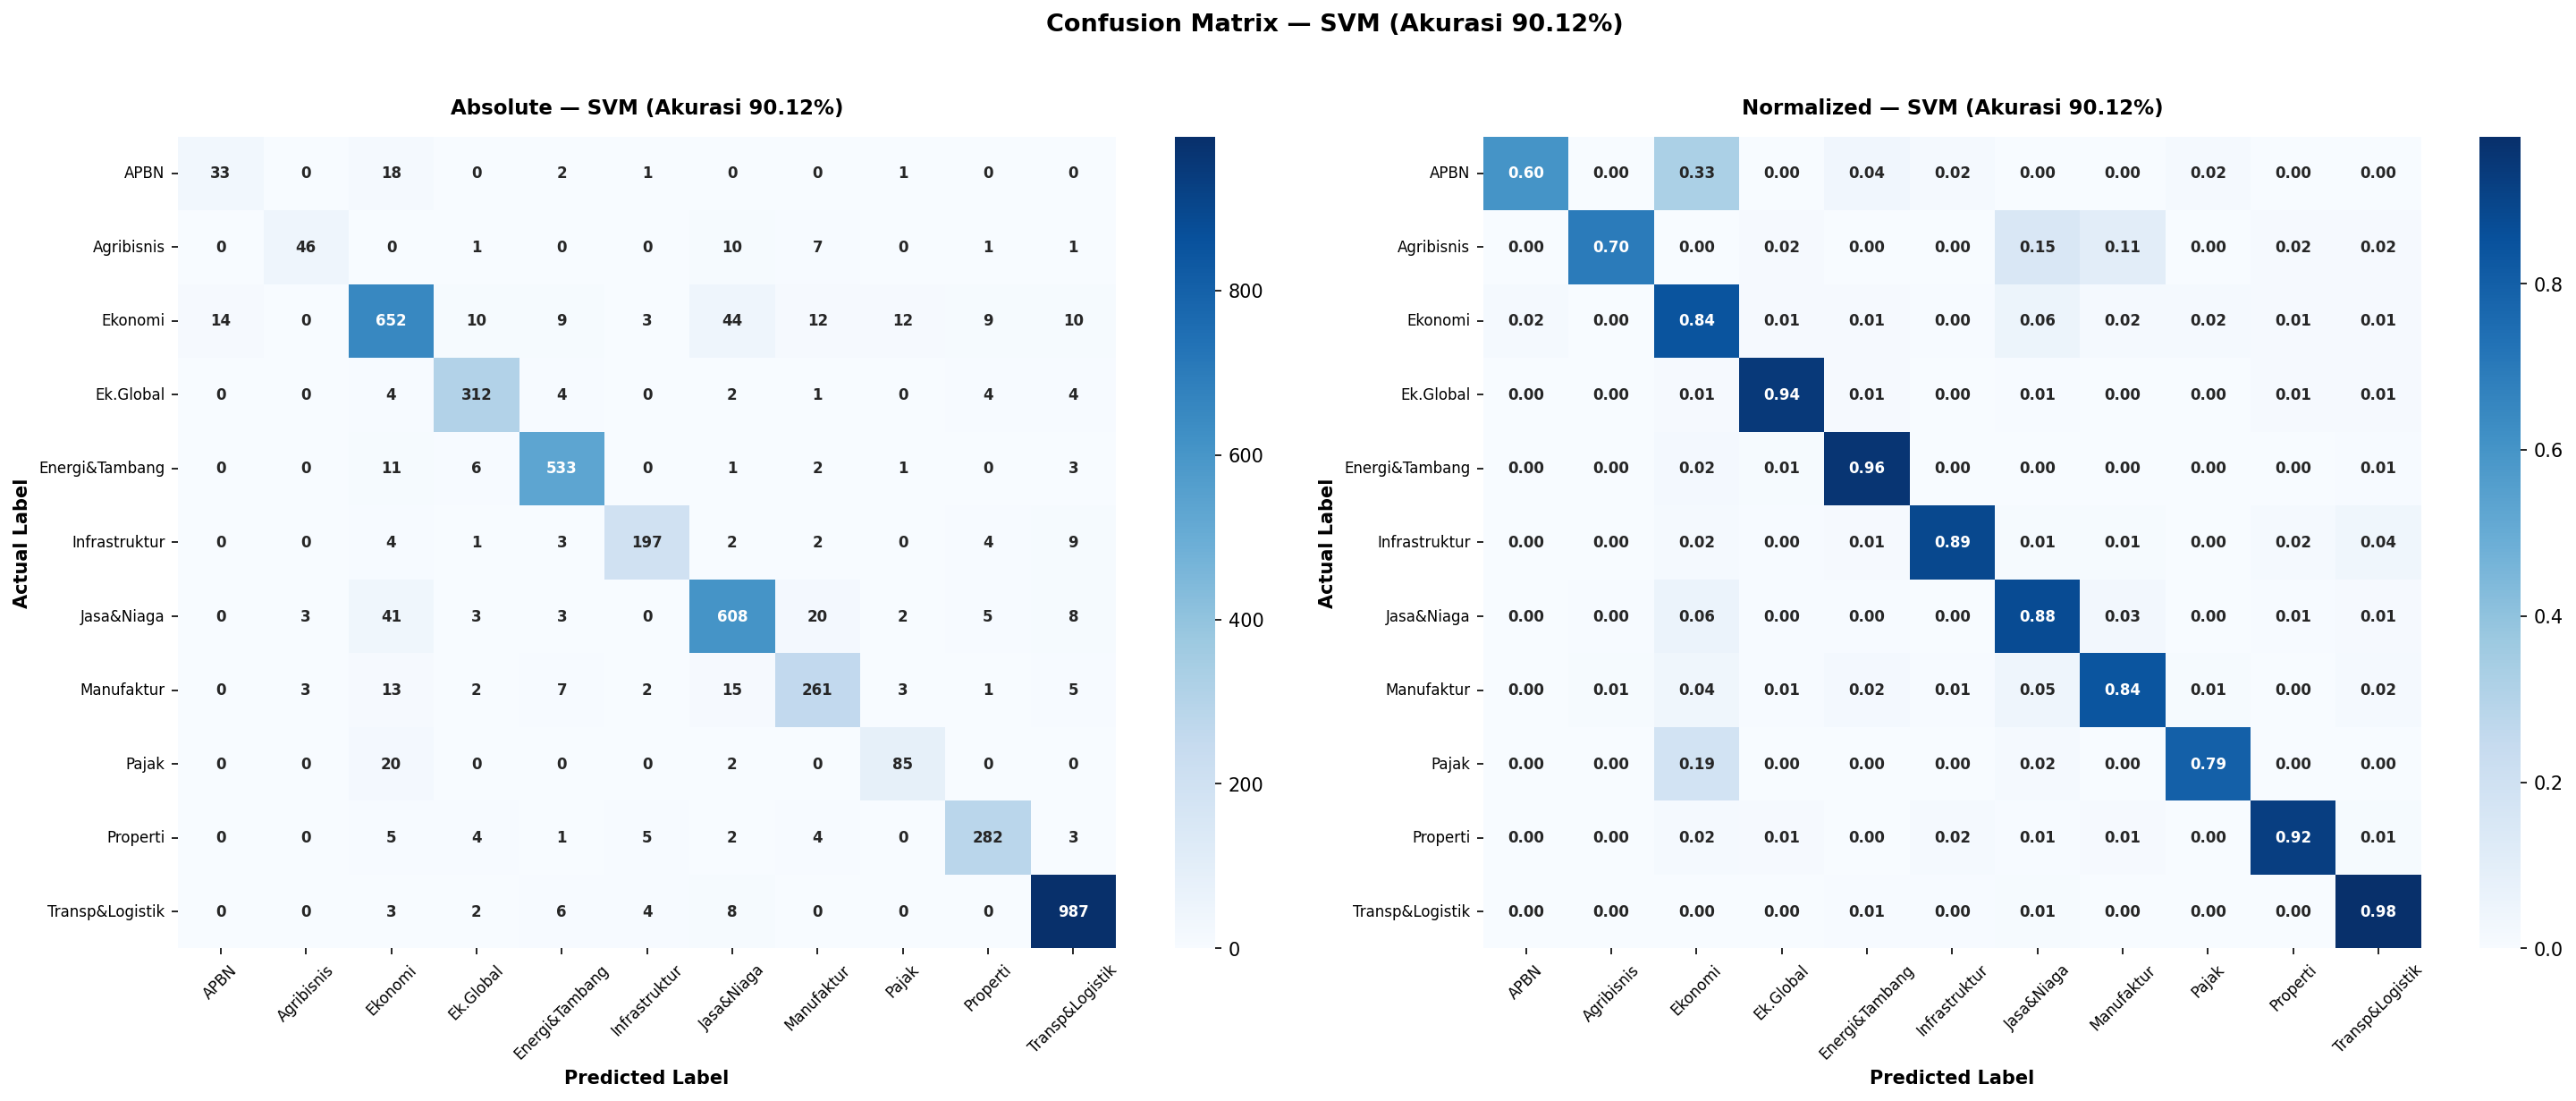

Tersimpan: ..\outputs\figures\Gambar_6_Confusion_Matrix_SVM.png


In [10]:
fname, (title, cm) = list(cms.items())[0]
plot_confusion_matrix_journal(title, cm, fname)  # SVM

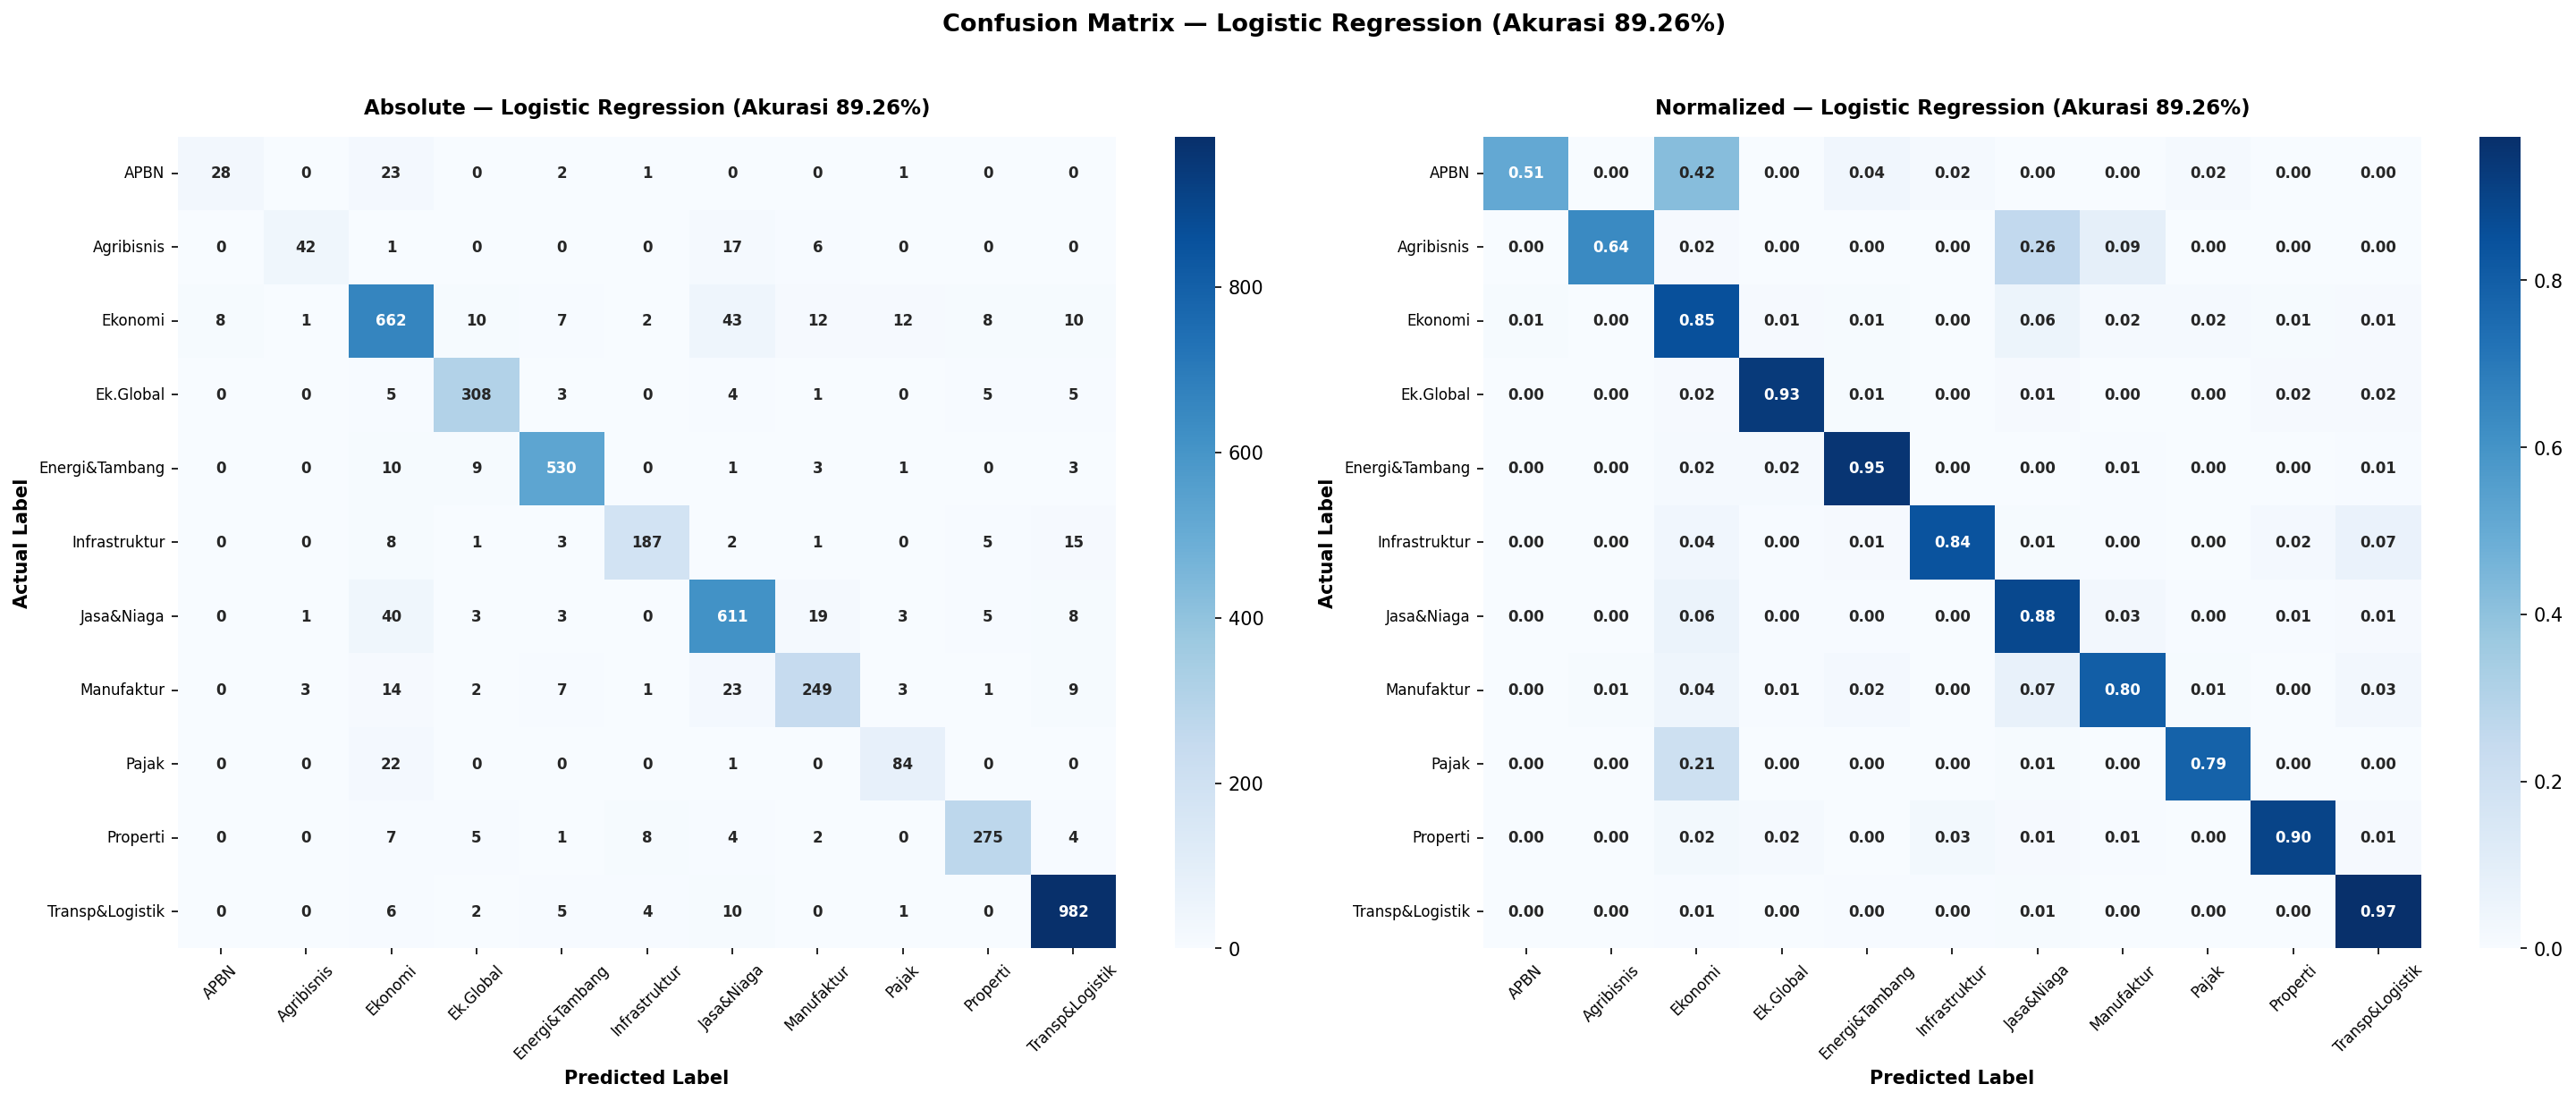

Tersimpan: ..\outputs\figures\Gambar_7_Confusion_Matrix_Logistic_Regression.png


In [11]:
fname, (title, cm) = list(cms.items())[1]
plot_confusion_matrix_journal(title, cm, fname)  # Logistic Regression

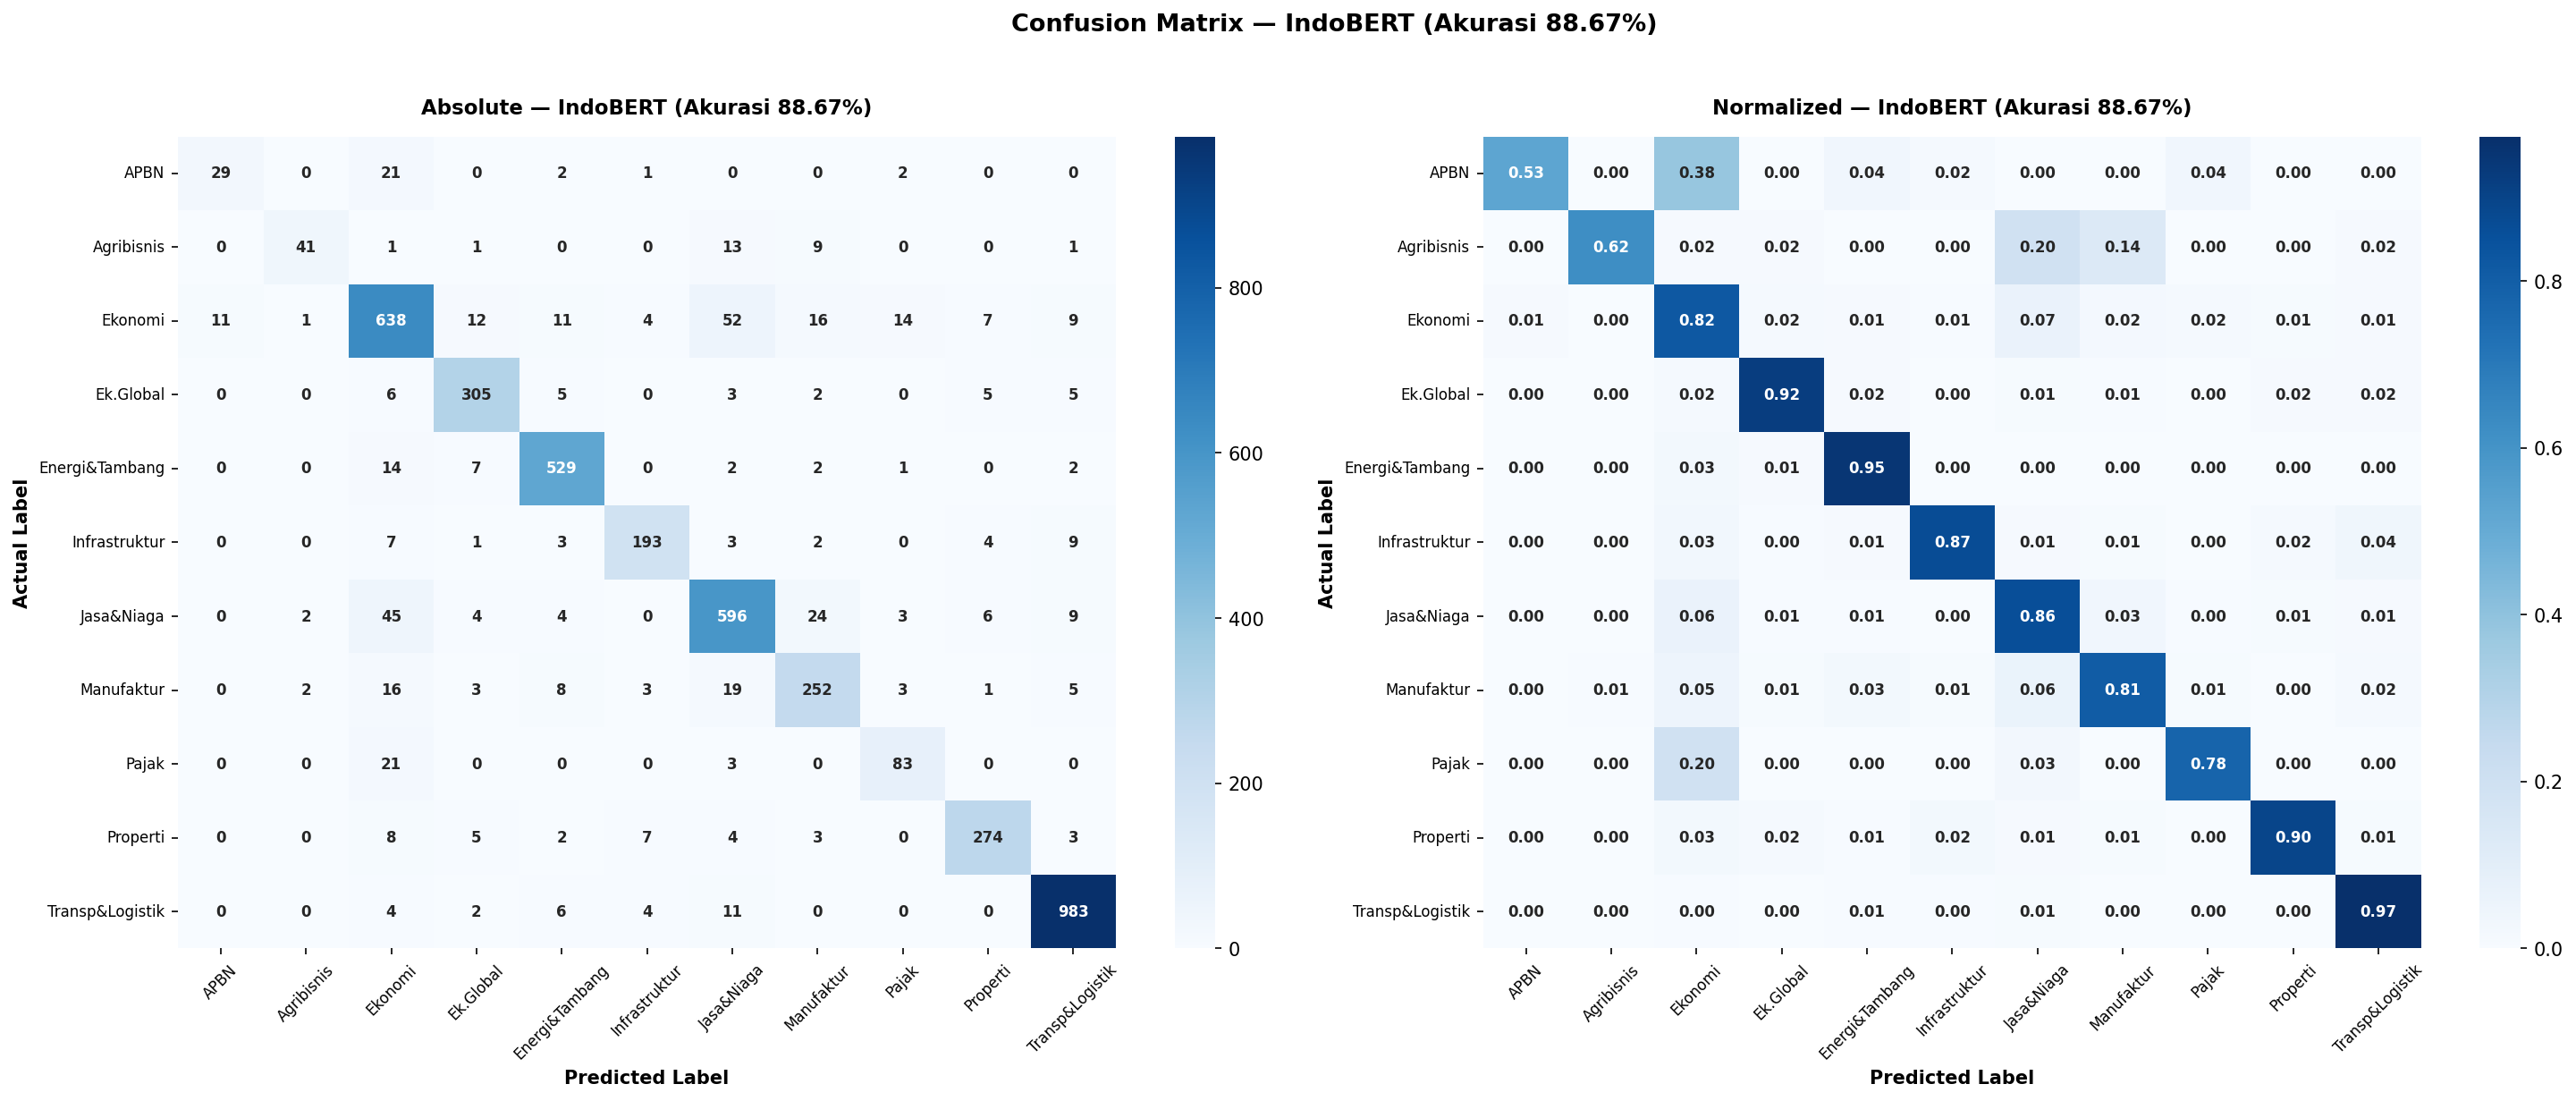

Tersimpan: ..\outputs\figures\Gambar_8_Confusion_Matrix_IndoBERT.png


In [12]:
fname, (title, cm) = list(cms.items())[2]
plot_confusion_matrix_journal(title, cm, fname)  # IndoBERT

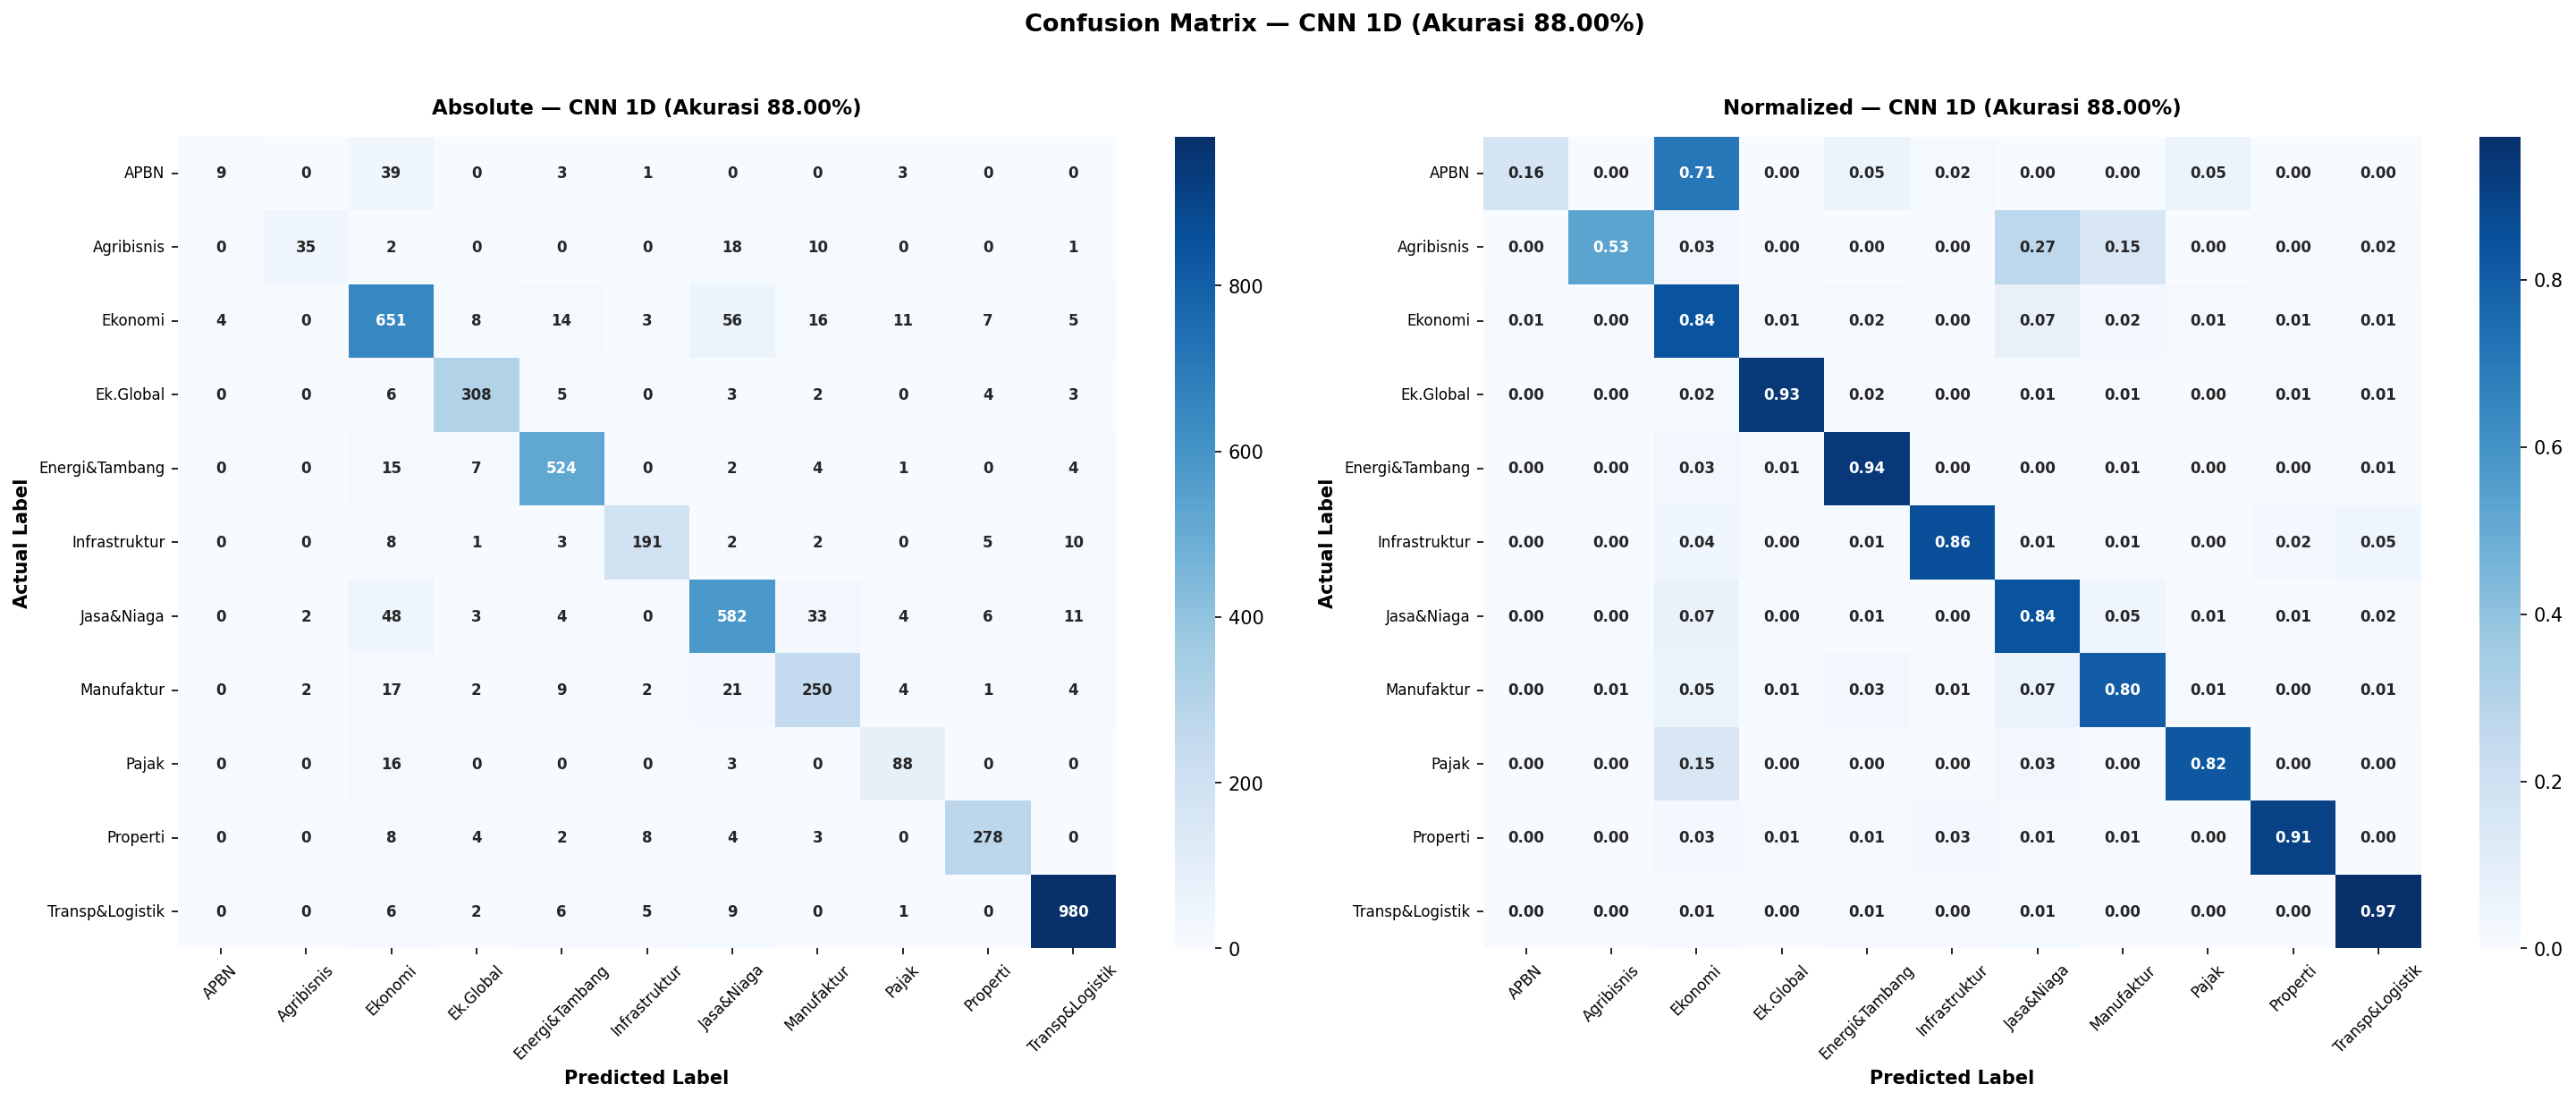

Tersimpan: ..\outputs\figures\Gambar_9_Confusion_Matrix_CNN_1D.png


In [13]:
fname, (title, cm) = list(cms.items())[3]
plot_confusion_matrix_journal(title, cm, fname)  # CNN 1D

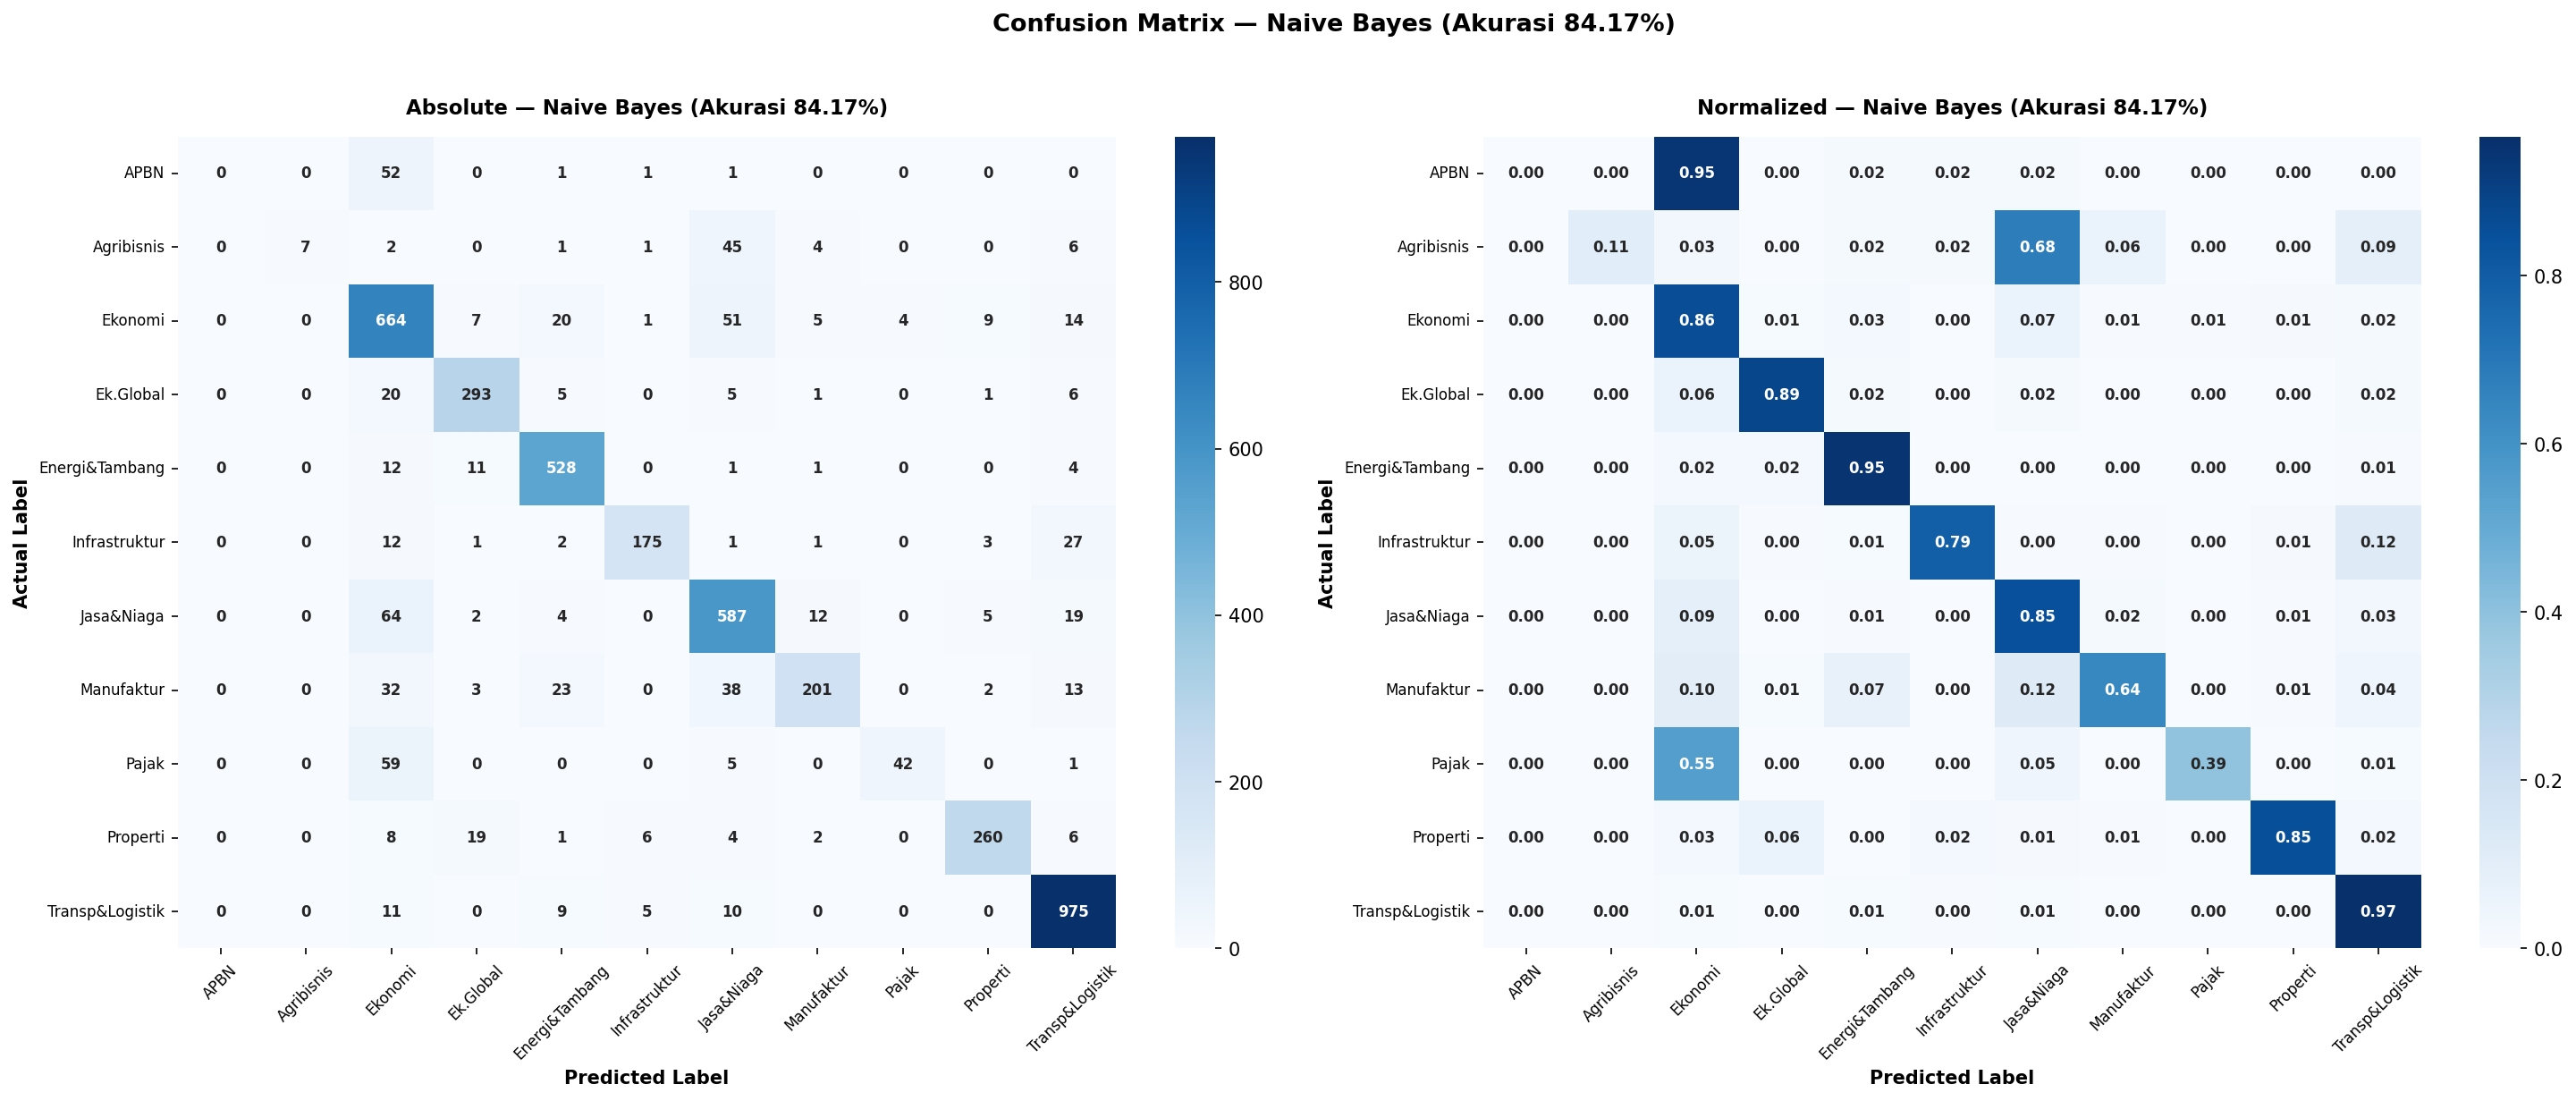

Tersimpan: ..\outputs\figures\Gambar_10_Confusion_Matrix_Naive_Bayes.png


In [14]:
fname, (title, cm) = list(cms.items())[4]
plot_confusion_matrix_journal(title, cm, fname)  # Naive Bayes

---
## 8. Bar Chart Perbandingan Akurasi Semua Model

In [15]:
summary = {
    'Model':            ['SVM', 'Logistic Regression', 'IndoBERT', 'CNN 1D', 'CNN-BiLSTM', 'BiLSTM', 'Naive Bayes'],
    'Akurasi Test (%)': [90.12,  89.26,               88.95,      87.41,    84.84,        84.75,    84.17],
    'Catatan':          ['N/A',  'N/A',               'Epoch 2',  'Epoch 2','Epoch 2',   'Epoch 2', 'N/A']
}
df_summary = pd.DataFrame(summary).sort_values('Akurasi Test (%)', ascending=False).reset_index(drop=True)
df_summary.index += 1
display(df_summary)

,Model,Akurasi Test (%),Catatan
1,SVM,90.12,N/A
2,Logistic Regression,89.26,N/A
3,IndoBERT,88.95,Epoch 2
4,CNN 1D,87.41,Epoch 2
5,CNN-BiLSTM,84.84,Epoch 2
6,BiLSTM,84.75,Epoch 2
7,Naive Bayes,84.17,N/A


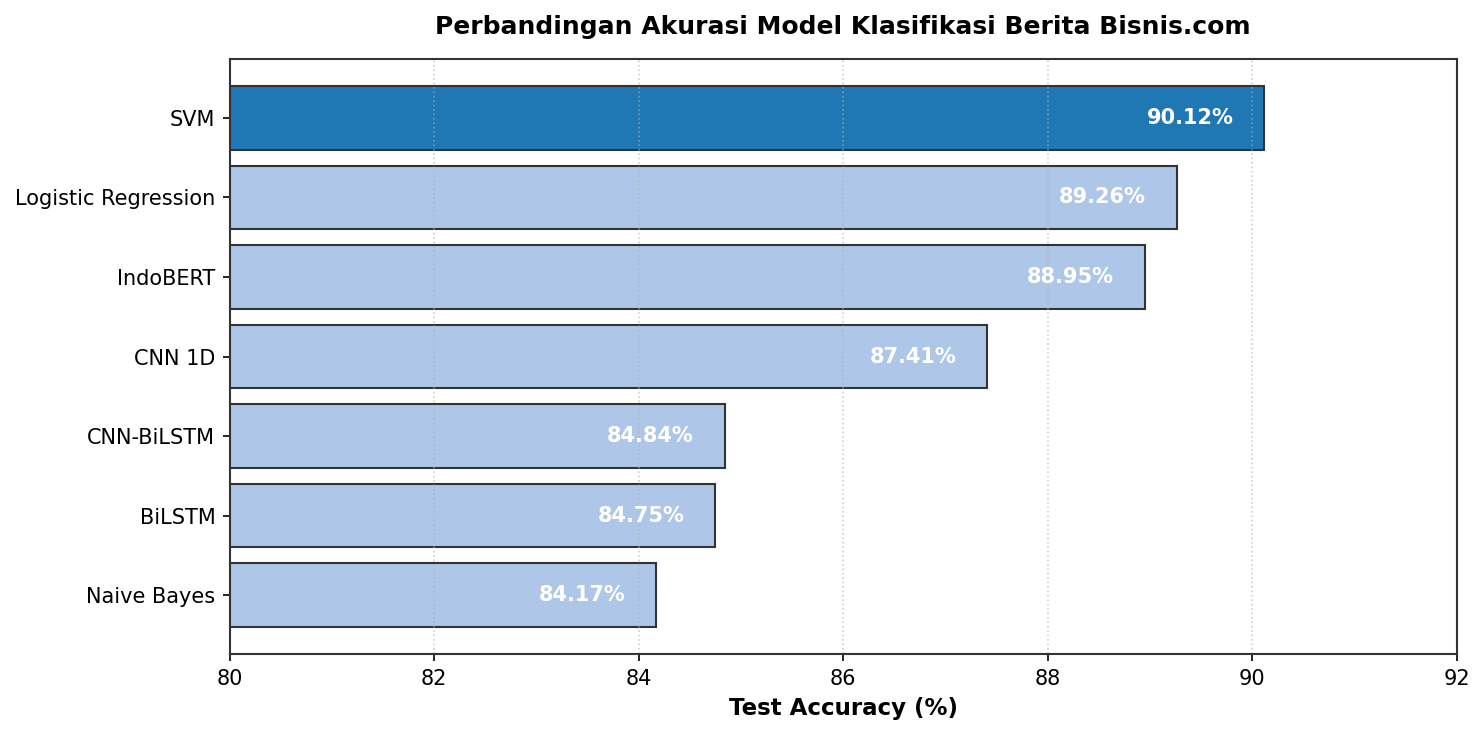

Tersimpan: ..\outputs\figures\Gambar_11_Perbandingan_Akurasi_Model.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
best_val = df_summary['Akurasi Test (%)'].max()
colors = ['#1f77b4' if v == best_val else '#aec7e8' for v in df_summary['Akurasi Test (%)']]
bars = ax.barh(df_summary['Model'], df_summary['Akurasi Test (%)'], color=colors, edgecolor='#333')

for bar, val in zip(bars, df_summary['Akurasi Test (%)']):
    ax.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='right', fontsize=10, fontweight='bold', color='white')

ax.set_xlabel('Test Accuracy (%)', fontsize=11, fontweight='bold')
ax.set_title('Perbandingan Akurasi Model Klasifikasi Berita Bisnis.com',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(80, 92)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.invert_yaxis()
plt.tight_layout()

out_path = os.path.join(output_dir, 'Gambar_11_Perbandingan_Akurasi_Model.png')
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f"Tersimpan: {out_path}")

---
## Selesai!

Seluruh gambar berhasil di-generate dan tersimpan di `outputs/figures/`:

| Gambar | Deskripsi |
|--------|------------|
| Gambar 2 | Kurva Training vs Validasi — CNN 1D |
| Gambar 3 | Kurva Training vs Validasi — BiLSTM |
| Gambar 4 | Kurva Training vs Validasi — CNN-BiLSTM |
| Gambar 5 | Kurva Training vs Validasi — IndoBERT |
| Gambar 6 | Confusion Matrix — SVM |
| Gambar 7 | Confusion Matrix — Logistic Regression |
| Gambar 8 | Confusion Matrix — IndoBERT |
| Gambar 9 | Confusion Matrix — CNN 1D |
| Gambar 10 | Confusion Matrix — Naive Bayes |
| Gambar 11 | Bar Chart Perbandingan Akurasi Semua Model |